In [1]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

from dotenv import load_dotenv

In [2]:
# ----------------------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------------------

store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Vikram"})
store.put(user_details, "profile_2", {"data": "Profession: AI Engineer"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "preference_3", {"data": "Currently in learning phase and looking for job roles related to GenAI"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [3]:
# ----------------------------------------
# 2) System prompt template (your prompt)
# ----------------------------------------

SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
- Always address the user by name (e.g., "Sure, Nitish...") when appropriate
- Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
- Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
- Greetings and transitions
- Help or guidance tailored to tools and frameworks the user uses
- Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumptions.

In the end suggest 3 relevant further questions based on the current response and user context.

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
# 3) Build graph: START → chat -> END (read-only LTM)

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [5]:

def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for fuser_details_content}
    # Keep it dead simple for teaching.

    if items:
        user_details_content = "\n".join(f"-{it.value.get('data', '')}" for it in items)
    else:
        user_details_content = "" # prompt says it maybe empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content = user_details_content
    )

    system_message = SystemMessage(content=system_prompt)

    response = llm.invoke([system_message] + state['messages'])
    return {'messages': [response]}

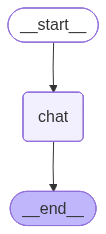

In [6]:
builder = StateGraph(MessagesState)

builder.add_node('chat', chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)
graph

In [7]:
# 4) Run it (provide user_id in config)

config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {'messages': [HumanMessage(content='Explain gen ai in simple terms.')]},
    config
)

print(result['messages'][-1].content)

Vikram, as an AI Engineer, you're likely familiar with the basics, but I'll break it down for you in simple terms. General AI, or Gen AI, refers to a type of artificial intelligence that can perform any intellectual task that a human can. It's like a super-smart, all-knowing AI that can learn, reason, and apply its knowledge to solve complex problems.

Think of it like a human brain, but instead of neurons, it's made up of complex algorithms and data structures. Gen AI can understand natural language, learn from experience, and even exhibit creativity. It's the holy grail of AI research, and many companies are working on developing Gen AI models that can assist humans in various industries.

To give you a better idea, here's a simple Python example using the Hugging Face Transformers library to demonstrate a basic Gen AI model:
```python
from transformers import pipeline

# Load the Gen AI model
gen_ai_model = pipeline("text-generation")

# Define a prompt
prompt = "Write a short story

### Chatbot Creating New Memories

In [8]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

In [9]:
# 2) LLM that decides what to remember (structured output)

extractor_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [10]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description='Whether to store any memories')
    memories: List[str] = Field(default_factory=list ,description="Atomic user memories")

In [11]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [12]:
# 3) Graph: START - remember → END
# (Creates memories, but does NOT use them to answer)

def remember_only_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            HumanMessage(content=last_msg)
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # No reasoning, just acknowledgment
    return {'messages': [AIMessage(content='Noted.')]}

In [13]:
builder = StateGraph(MessagesState)

builder.add_node('remember', remember_only_node)
builder.add_node('chat', chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [14]:
# ----------------------------------------
# 4) Demo
# ----------------------------------------

config = {"configurable": {"user_id": "u1"}}

# Use HumanMessage (recommended)
res = graph.invoke(
    {"messages": [HumanMessage(content="Hi my name is Vikram")]},
    config
)
print("Assistant:", res["messages"][-1].content)


res = graph.invoke(
    {"messages": [HumanMessage(content="I am a GenAI Engineer")]},
    config
)
print("Assistant:", res["messages"][-1].content)


res = graph.invoke(
    {"messages": [HumanMessage(content="My favorite programming language is Python and CPP")]},
    config
)
print("Assistant:", res["messages"][-1].content)

Assistant:  Your name is Vikram. I'll keep that in mind for our conversation. 

Since we're starting fresh, I'd like to know how I can assist you today. Are you looking for help with your MCP server project, or perhaps guidance on your GenAI learning journey?
Assistant:  You're a GenAI Engineer, which means you're likely working with cutting-edge AI technologies. I'll keep that in mind as we chat.

Since you're in the learning phase and looking for job roles related to GenAI, I'd like to help you explore some exciting opportunities. Can you tell me a bit more about what you're looking for in a GenAI role? Are you interested in research, development, or application of GenAI technologies?

Also, I noticed you mentioned building MCP servers with Python. How's that project going? Do you have any specific challenges or areas where you'd like some guidance?

Here are three relevant further questions based on our conversation:

1. What specific areas of GenAI are you most interested in (e.g.,

In [15]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

Name: Vikram
Profession: AI Engineer
Prefers concise answers
Likes examples in Python
Currently in learning phase and looking for job roles related to GenAI
Building MCP servers (Python-based project)
My name is Vikram
I am a GenAI Engineer
I like Python
I like C++


### Chatbot Creating New Memories(without Duplication)

In [ ]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [17]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [18]:
class MemoryItem(BaseModel):

    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [19]:
class MemoryDecision(BaseModel):

    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [20]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [21]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""


In [22]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [
        it.value.get("data", "")
        for it in existing_items
        if it.value.get("data")
    ]

    user_details_content = (
        "\n".join(f"- {t}" for t in existing_texts)
        if existing_texts else "(empty)"
    )

    # B) Latest user message
    last_text = state["messages"][-1].content

    # C) LLM extracts memories
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=MEMORY_PROMPT.format(
                    user_details_content=user_details_content
                )
            ),
            HumanMessage(content=f"USER MESSAGE:\n{last_text}")
        ]
    )

    existing_set = set(existing_texts)

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new and mem.text not in existing_set:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [AIMessage(content="Noted.")]}

In [23]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [24]:
config = {"configurable": {"user_id": "u1"}}

In [28]:
r1 = graph.invoke(
    {"messages": [HumanMessage(content="My name is Vikram")]},
    config
)
print("Assistant:", r1["messages"][-1].content)


# Likely duplicate → is_new should be False → saved = 0
r2 = graph.invoke(
    {"messages": [HumanMessage(content="I like Python for programming.")]},
    config
)
print("\nAssistant:", r2["messages"][-1].content)

Assistant: Noted.

Assistant: Noted.


In [29]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

Name: Vikram
Profession: AI Engineer
Prefers concise answers
Likes examples in Python
Currently in learning phase and looking for job roles related to GenAI
Building MCP servers (Python-based project)
My name is Vikram
I am a GenAI Engineer
I like Python
I like C++


### Merged Workflow

In [30]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [ ]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [32]:
memory_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [33]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [34]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [35]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [36]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [37]:
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [38]:
chat_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [39]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

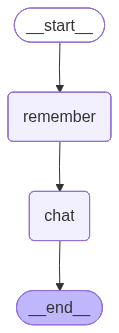

In [40]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph


In [41]:
config = {"configurable": {"user_id": "u1"}}

In [43]:
result = graph.invoke(

    {"messages": [HumanMessage(content="Hi, my name is Vikram")]},

    config

)

print(result["messages"][-1].content)

Hello Vikram, nice to virtually meet you. I've taken note of your name and profession as a GenAI Engineer. I'm here to assist you with any questions or topics you'd like to discuss. What's on your mind today? Are you working on a specific project, like your MCP server, or perhaps looking for guidance on GenAI-related topics?


In [44]:
result = graph.invoke(

    {"messages": [HumanMessage(content="AI Engineer")]},

    config

)

print(result["messages"][-1].content)

Nice to see you're referring to your profession, Vikram. As a GenAI Engineer, you're likely aware of the rapidly evolving landscape of artificial intelligence. I'd like to help you with any questions or concerns you may have.

Since you're currently in the learning phase and looking for job roles related to GenAI, I'd like to offer some guidance. Have you considered exploring the intersection of GenAI and natural language processing (NLP)? This area is gaining significant attention, and understanding how to integrate GenAI models with NLP techniques can be a valuable skill.

For instance, you could use the Hugging Face Transformers library in Python to fine-tune a pre-trained GenAI model on a specific NLP task, such as text classification or sentiment analysis. Here's a simple example to get you started:

```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Load pre-trained model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-engl

In [45]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Name: Vikram
Profession: AI Engineer
Prefers concise answers
Likes examples in Python
Currently in learning phase and looking for job roles related to GenAI
Building MCP servers (Python-based project)
My name is Vikram
I am a GenAI Engineer
I like Python
I like C++


In [46]:
result = graph.invoke(
    {"messages": [HumanMessage(content="Explain GenAI simply")]},
    config
)
print(result["messages"][-1].content)

Vikram, as a GenAI Engineer, you're likely familiar with the basics, but I'll break it down for you in simple terms. 

Generalized Artificial Intelligence (GenAI) refers to a hypothetical AI system that possesses human-like intelligence, capable of reasoning, problem-solving, and learning across a wide range of tasks, similar to how humans do. It's not just about processing data or performing specific tasks, but rather having a deep understanding of the world and being able to apply that knowledge in various contexts.

Think of it like this: a GenAI system would be able to:

- Understand natural language (like humans do)
- Learn from experience and adapt to new situations
- Reason and make decisions based on complex data
- Apply knowledge across multiple domains and tasks

While we're not yet at the level of true GenAI, researchers and engineers like yourself are working towards developing more advanced AI systems that can mimic human intelligence.

Now, let's dive deeper into the spec

In [47]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Name: Vikram
Profession: AI Engineer
Prefers concise answers
Likes examples in Python
Currently in learning phase and looking for job roles related to GenAI
Building MCP servers (Python-based project)
My name is Vikram
I am a GenAI Engineer
I like Python
I like C++
